In [ ]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

from ffnn.nn import MLP, Layer

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [47]:
X, y = make_moons(n_samples=300, noise=0.15, random_state=42)
y = y.reshape(-1, 1).astype(float) 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=67)
print(X_train.shape, y_train.shape)

(240, 2) (240, 1)


In [ ]:
model = MLP([
    Layer(16, activation='relu', weight_init='he'), 
    Layer(8, activation='relu', weight_init='he'),
], input_size=2, seed=67)

In [ ]:
model.add(Layer(1, activation='sigmoid', weight_init='xavier'))

In [50]:
model.summary()


Layer             Matrix Shape      Activation        Param #         
layer_1           (2, 16)           relu              48              
layer_2           (16, 8)           relu              136             
layer_3           (8, 1)            sigmoid           9               
Total parameters: 193



In [51]:
model.compile(optimizer={'method': 'sgd', 'learning_rate': 0.008}, loss='bce')

history = model.fit(
    X_train, y_train, 
    batch_size=16, 
    epochs=10000, 
    validation_data=(X_test, y_test), 
    verbose=1
)

Training FFNN:   0%|          | 0/10000 [00:00<?, ?it/s]

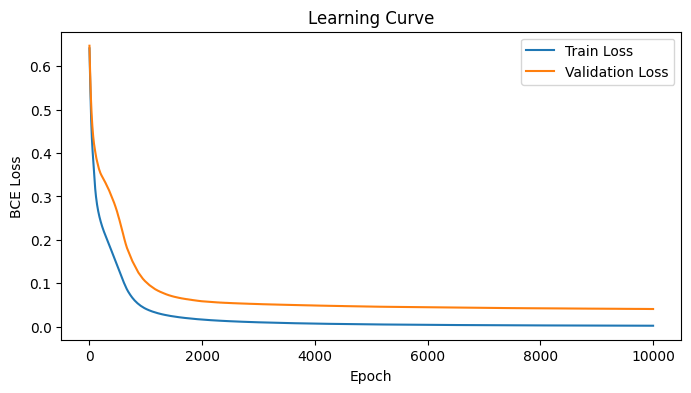

In [52]:
plt.figure(figsize=(8, 4))
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Learning Curve')
plt.xlabel('Epoch')
plt.ylabel('BCE Loss')
plt.legend()
plt.show()


Plotting weight distributions...


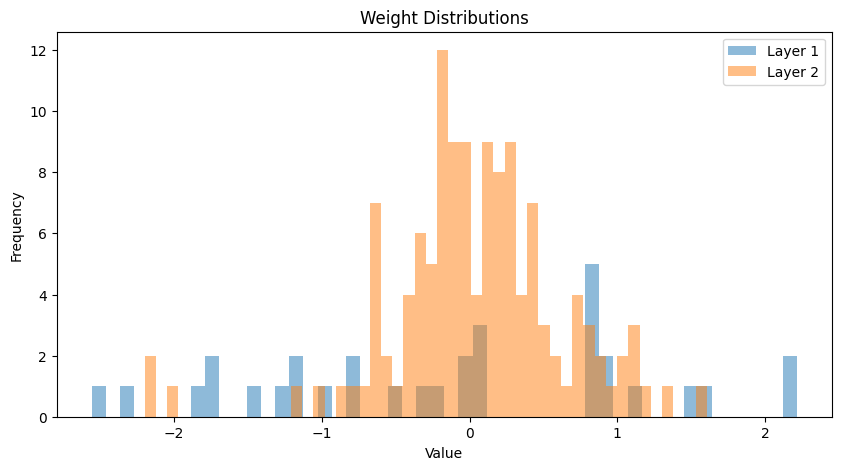

Plotting gradient distributions...


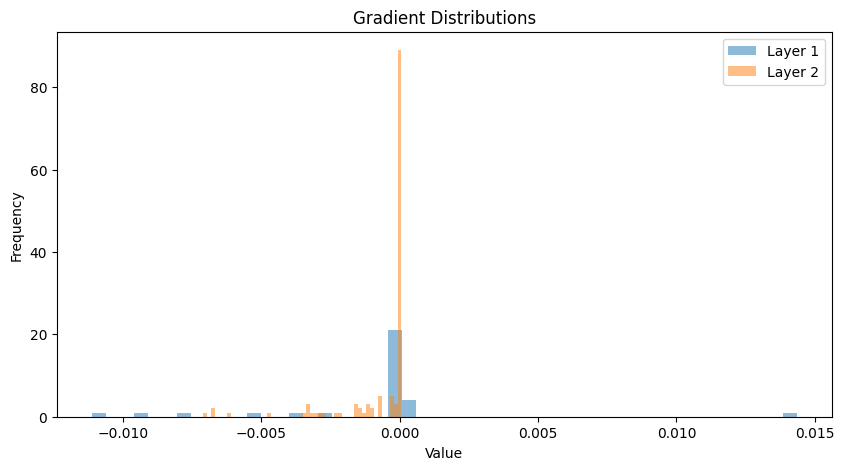

In [53]:
print("\nPlotting weight distributions...")
model.plot_weights(layer_indices=[0, 1])

print("Plotting gradient distributions...")
model.plot_gradients(layer_indices=[0, 1])

In [ ]:
model.save('../data/test_moons_model.pkl')

blank_model = MLP([
   Layer(16, activation='relu'), 
   Layer(1, activation='sigmoid'),
   Layer(1, activation='sigmoid')
], input_size=2)
blank_model.load('../data/test_moons_model.pkl')

Model successfully saved to ../data/test_moons_model.pkl
Model successfully loaded from ../data/test_moons_model.pkl
